In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
features = pd.read_csv("/home/robbe/MuMDIA/debug/outfile.pin", sep="\t")
psms = pd.read_csv("../results/config_playing/df_psms.tsv", sep="\t")

In [35]:
psms

,psm_id,filename,scannr,peptide,stripped_peptide,proteins,num_proteins,rank,is_decoy,expmass,...,matched_intensity_pct,scored_candidates,poisson,sage_discriminant_score,posterior_error,spectrum_q,peptide_q,protein_q,reporter_ion_intensity,fragment_intensity
0,1573,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=9771,AEGGSDER,AEGGSDER,sp|P10903|NARK_ECOLI|386|394,1,5,False,823.6175,...,1.991088,10,-0.399090,0.635878,-9.144547,0.058824,0.327426,0.327594,NaN,5778.0884
1,1572,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=9771,AGEKTYR,AGEKTYR,sp|P30126|LEUD_ECOLI|154|161,1,4,False,823.6175,...,1.991088,10,-0.399090,0.582951,-6.169283,0.058824,0.327426,0.327594,NaN,5778.0884
2,135,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=11454,TGGGAKGNNASPAGSGNTK,TGGGAKGNNASPAGSGNTK,sp|P19934|TOLA_ECOLI|309|328,1,3,False,1647.2350,...,14.408293,10,-0.399090,0.569689,-5.489716,0.058824,0.327426,0.327594,NaN,14769.8490
3,2241,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=19582,AANTGPHAAR,AANTGPHAAR,sp|P0ADH5|FIMB_ECOLI|23|33,1,4,False,967.6829,...,4.966263,4,-0.399090,0.427336,-0.671581,0.058824,0.327426,0.327594,NaN,6838.0205
4,2511,part_0.0_783.2013244628906.mzml,controllerType=0 controllerNumber=1 scan=8718,KPGSAAASGPK,KPGSAAASGPK,sp|P0AA80|GARP_ECOLI|228|239,1,5,False,967.6829,...,1.646909,5,-0.399090,0.400636,-0.551443,0.058824,0.334264,0.334450,NaN,5298.7236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6895736,28313250,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=230359,GLPHNVATKGGVSSDVQSLLTTPVQIFR,GLPHNVATKGGVSSDVQSLLTTPVQIFR,rev_sp|P07639|AROB_ECOLI|212|240,1,15,True,2915.0542,...,1.886076,15,-0.399090,-0.788482,-0.239177,0.998956,1.000000,1.000000,NaN,6062.3057
6895737,28323411,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=235604,VSASNGYYPENLAFPSTKIFTSIFR,VSASNGYYPENLAFPSTKIFTSIFR,rev_sp|P04152|UMUC_ECOLI|112|137,1,37,True,2814.2515,...,2.257099,73,-0.399090,-0.788485,-0.239167,0.998956,1.000000,1.000000,NaN,5381.6064
6895738,28314945,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=229854,QRSLYIPYAGPVLLEFPLLNK,QRSLYIPYAGPVLLEFPLLNK,sp|P26616|MAO1_ECOLI|7|28,1,6,False,2446.0842,...,2.885456,24,-0.407381,-0.788575,-0.238836,0.999536,1.000000,1.000000,NaN,6749.7075
6895739,28322986,part_8615.214569091797_9398.415893554688.mzml,controllerType=0 controllerNumber=1 scan=235515,IDVLQLAQVLRQTITK,IDVLQLAQVLRQTITK,rev_sp|P52140|YFJY_ECOLI|22|38,1,4,True,1834.5632,...,2.278465,10,-0.399090,-0.788578,-0.238836,0.999652,1.000000,1.000000,NaN,8583.5570


In [36]:
features = features.merge(
    psms[["psm_id", "is_decoy"]], left_on="PSMId", right_on="psm_id", how="left"
)

In [37]:
features["Label"] = features["is_decoy"].apply(lambda x: -1 if x else 1)
features = features.drop(columns=["is_decoy", "psm_id"])

In [38]:
df_targets = features[features["Label"] == 1.0]
df_decoys = features[features["Label"] == -1.0]

In [40]:
import re

features["ScanNr"] = features["ScanNr"].apply(
    lambda x: int(re.findall(r"\d+", x)[2]) if isinstance(x, str) else x
)

In [44]:
features.rename(columns={"PSMId": "SpecID"}, inplace=True)

In [46]:
features.to_csv("./outfile.pin", sep="\t")

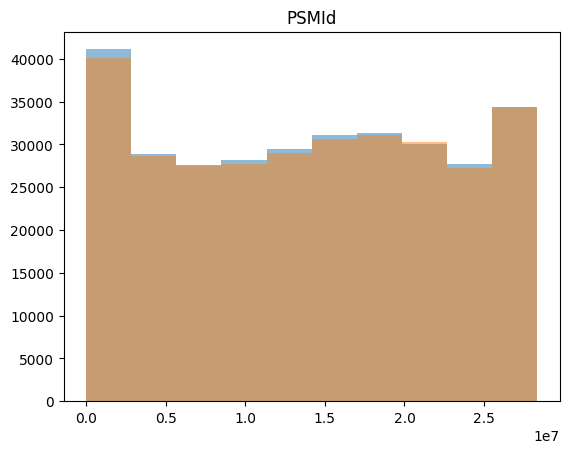

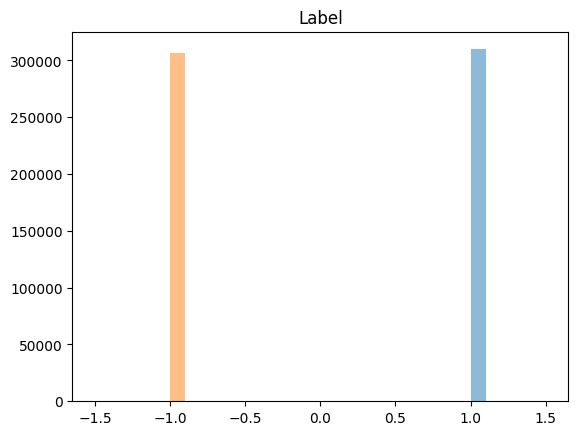

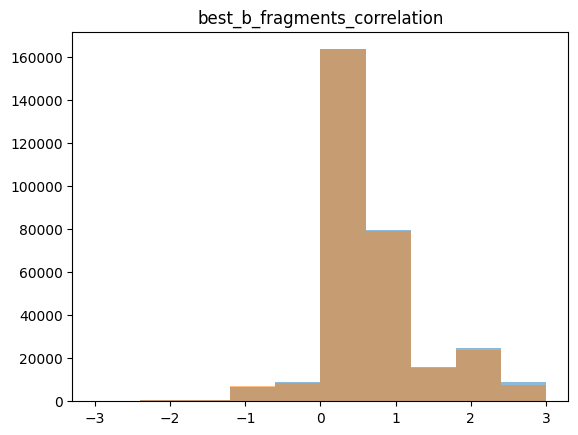

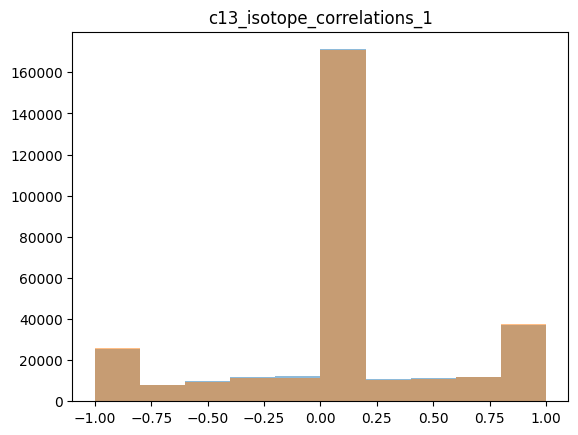

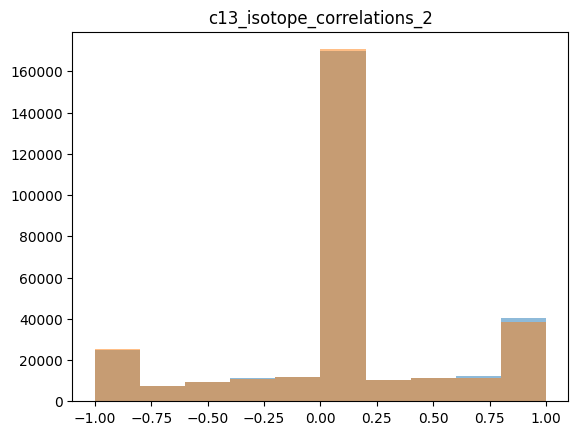

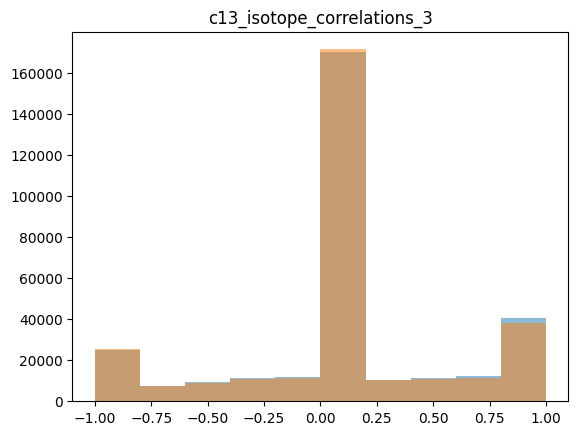

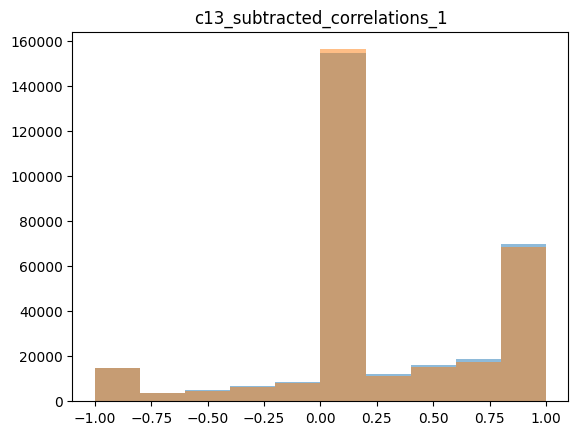

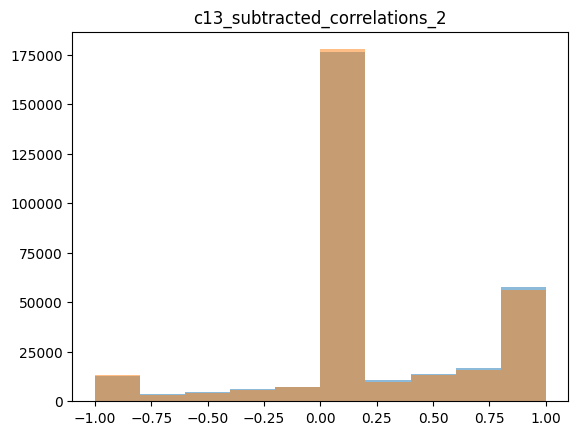

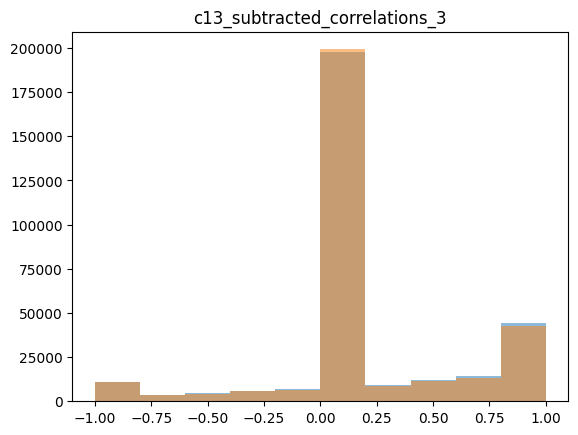

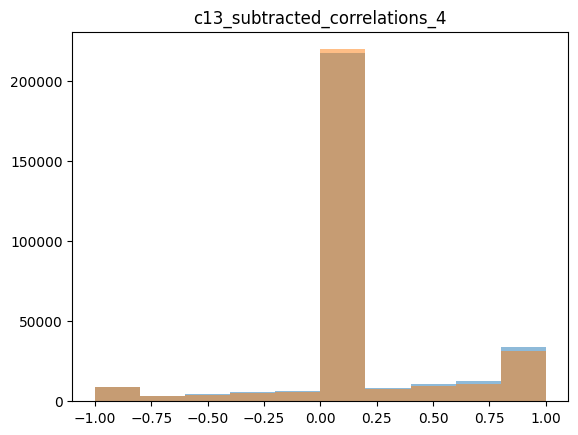

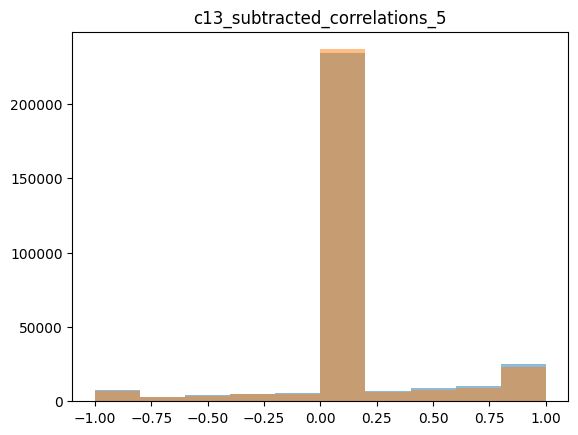

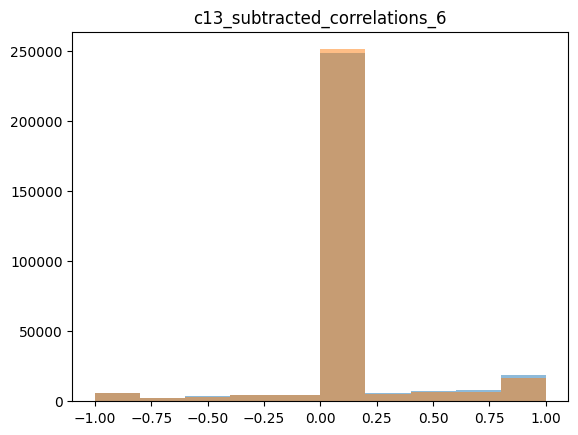

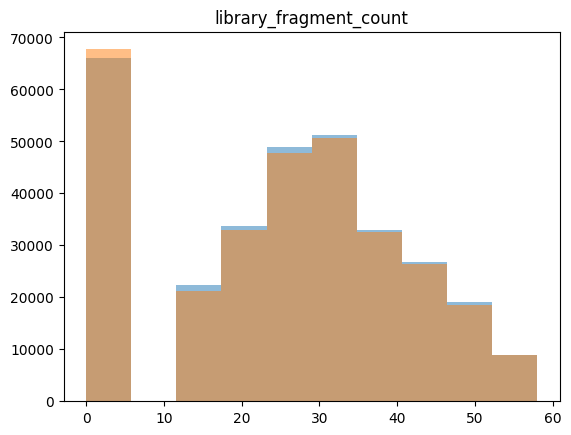

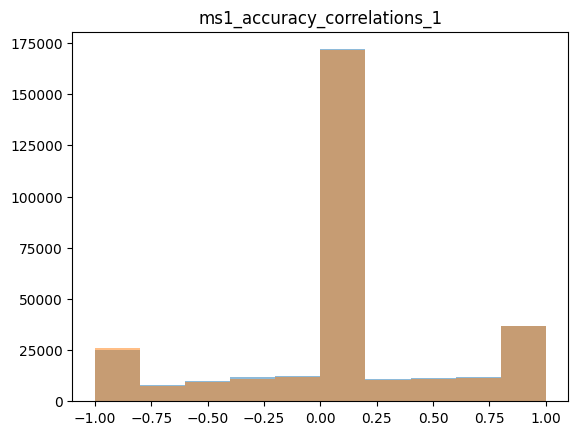

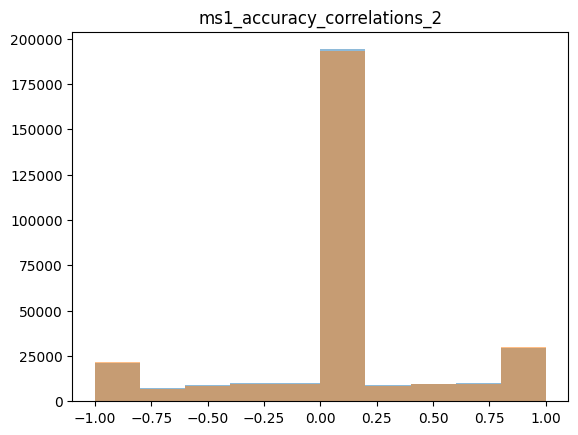

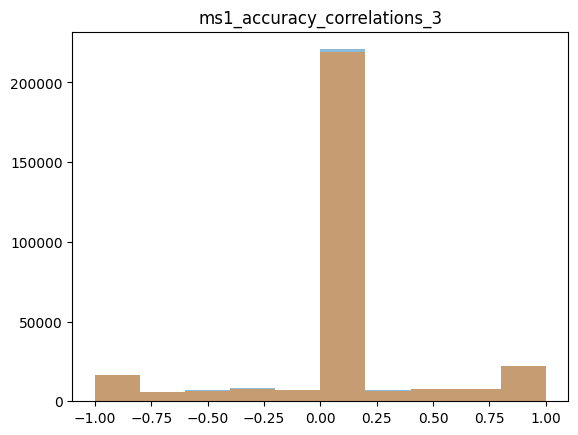

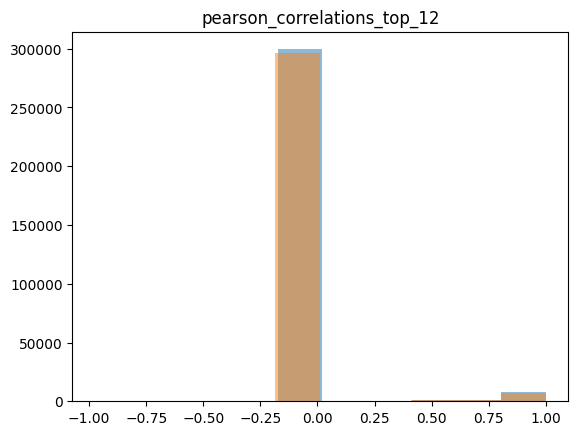

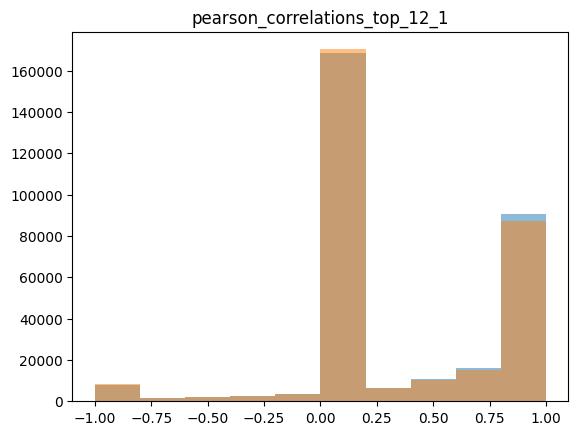

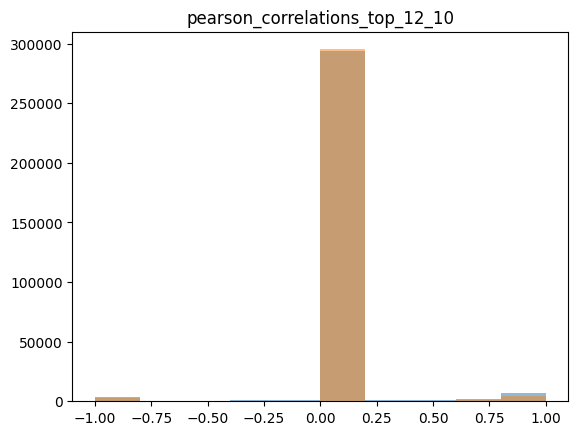

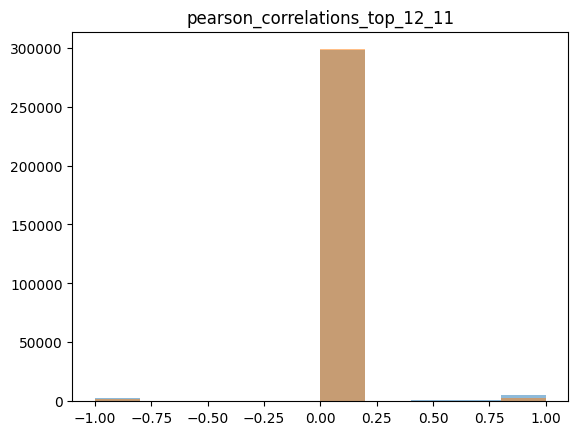

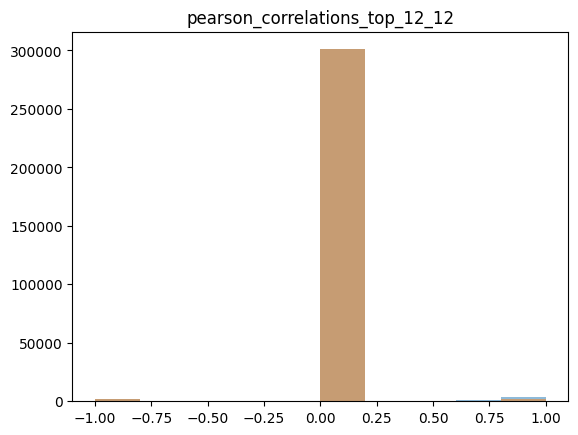

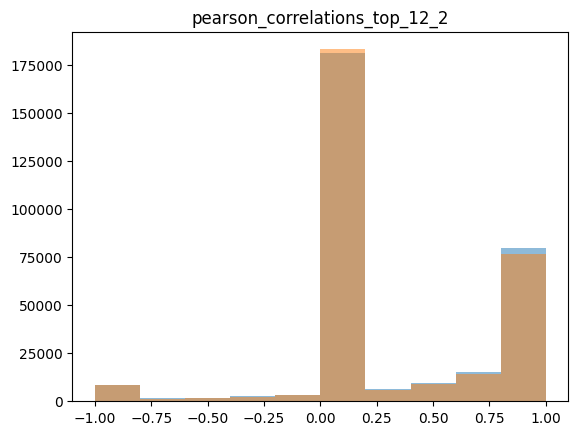

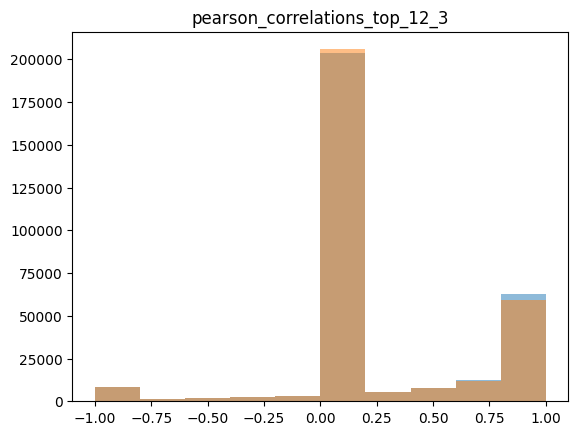

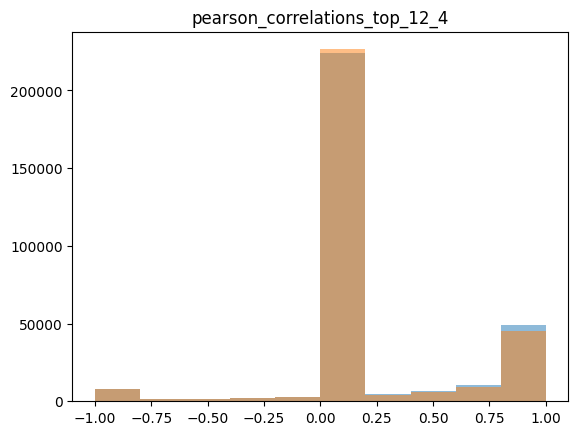

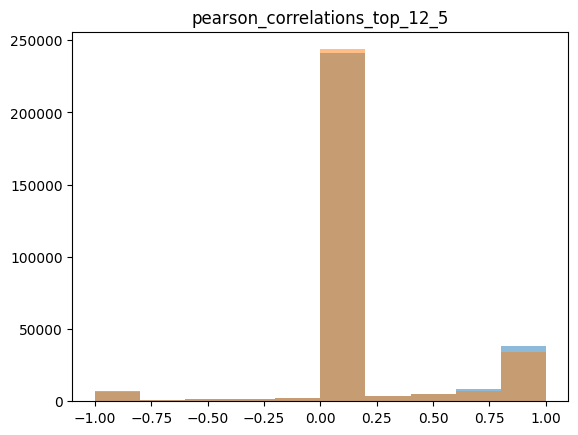

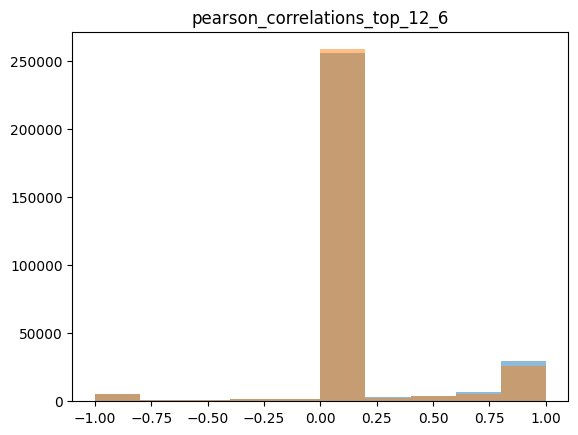

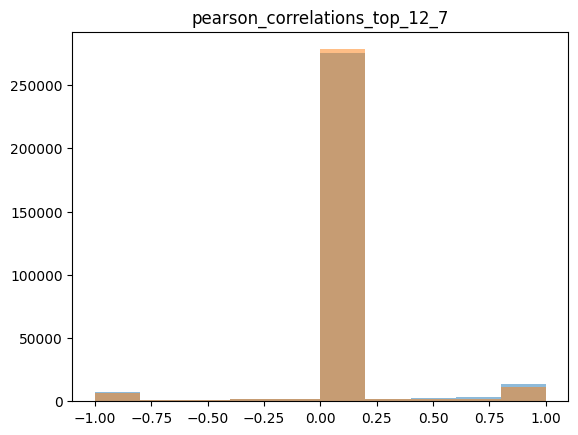

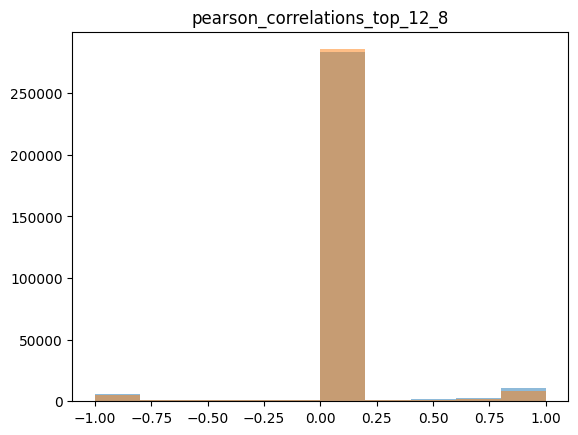

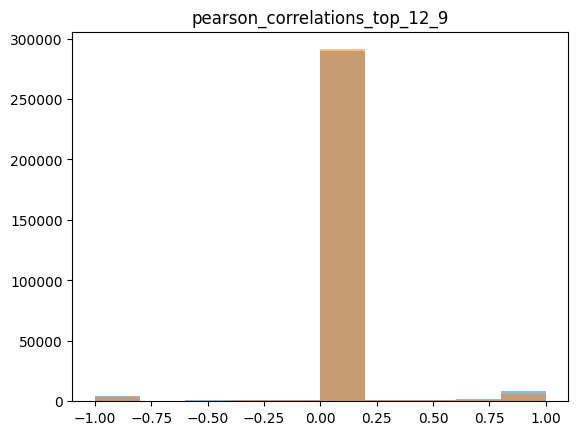

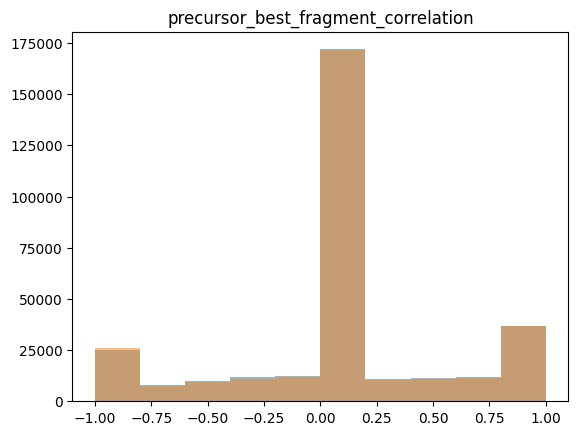

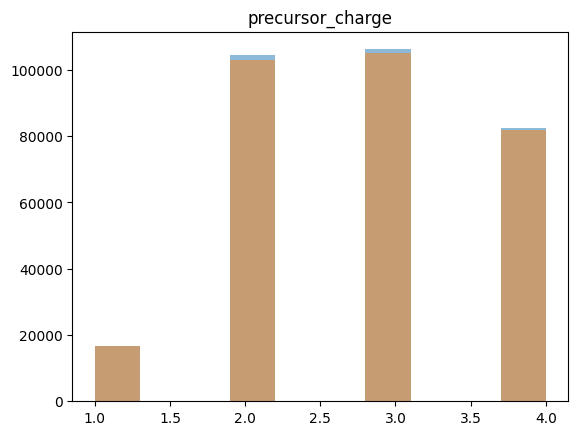

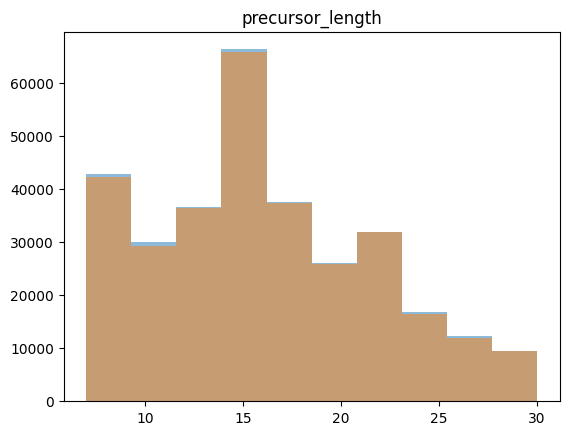

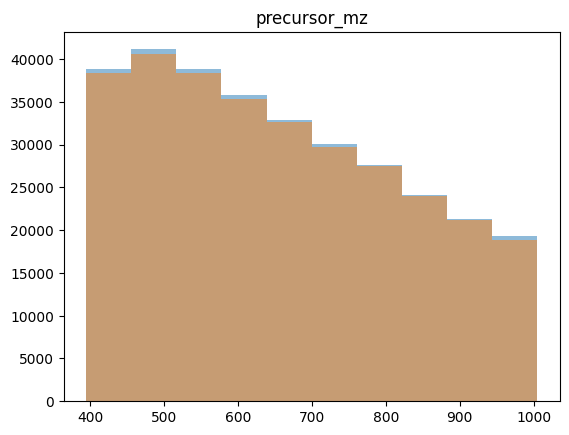

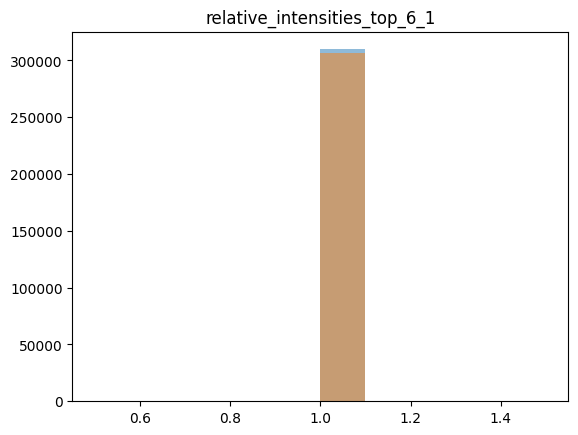

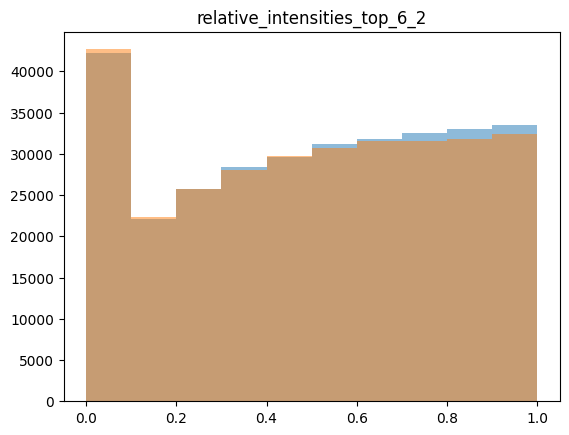

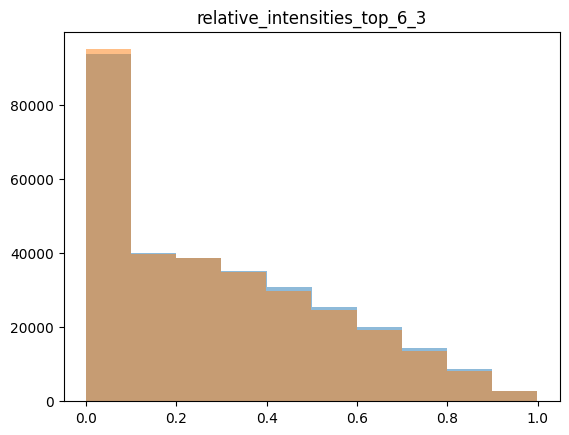

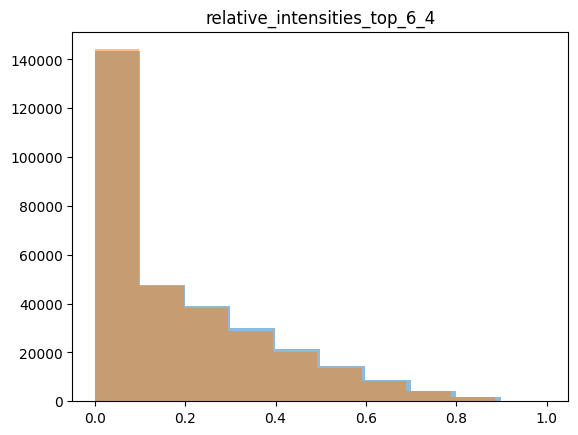

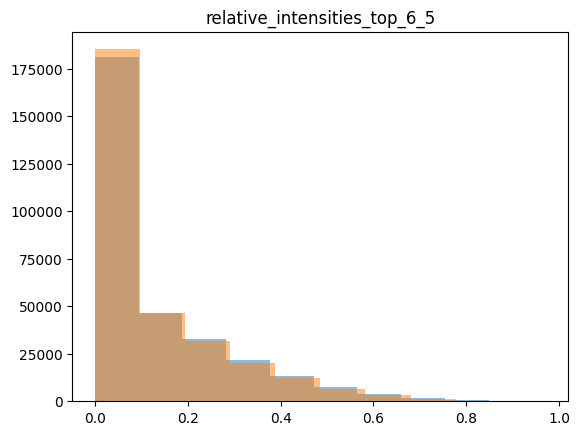

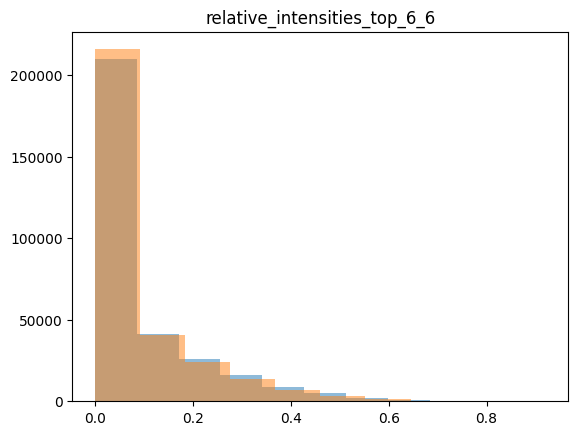

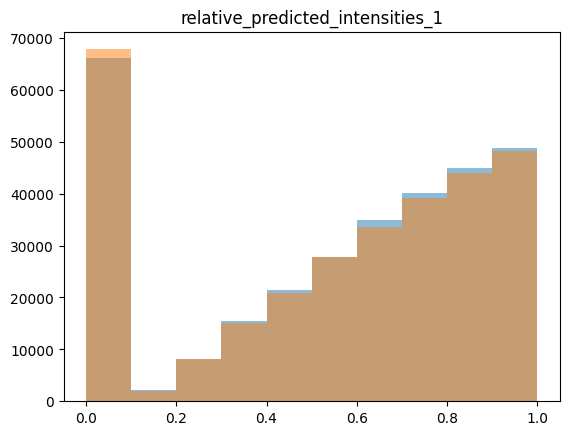

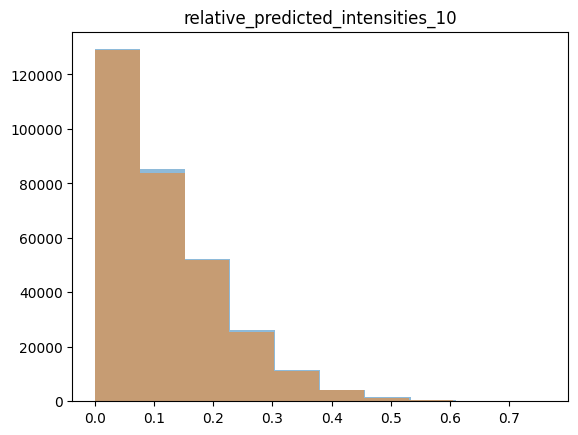

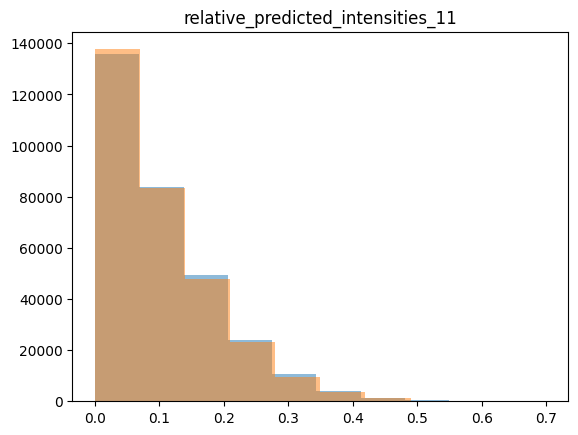

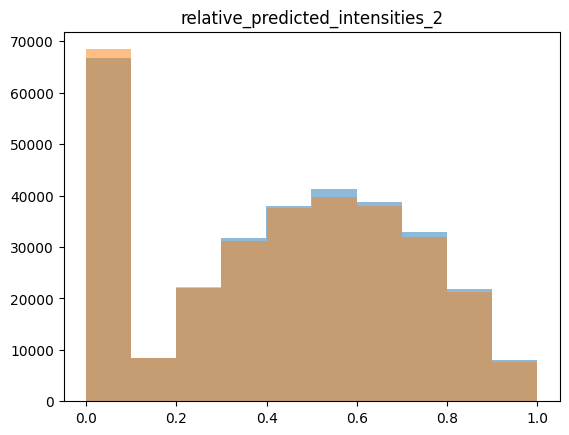

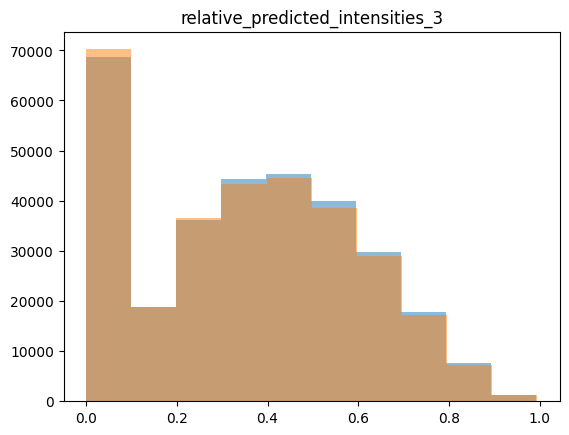

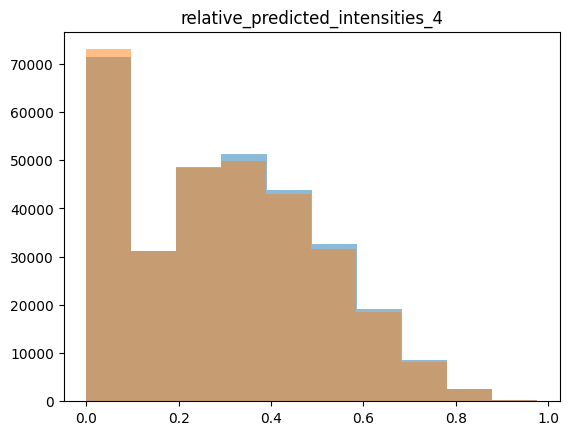

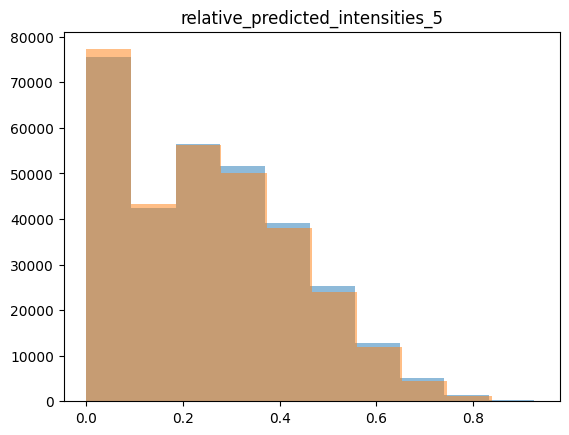

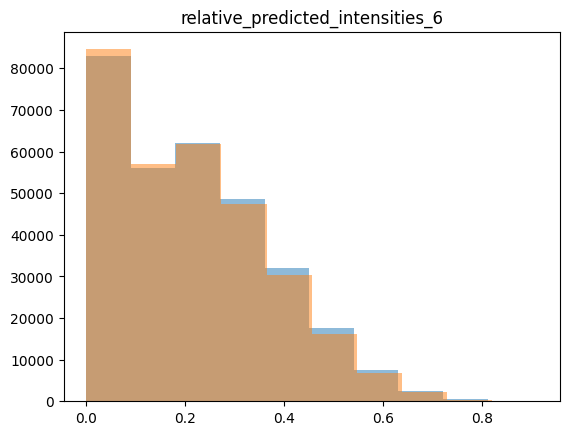

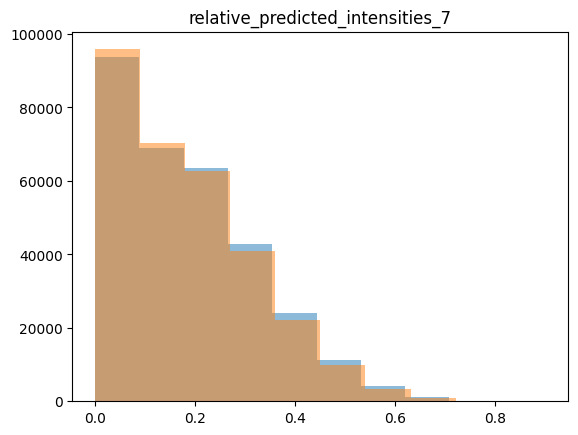

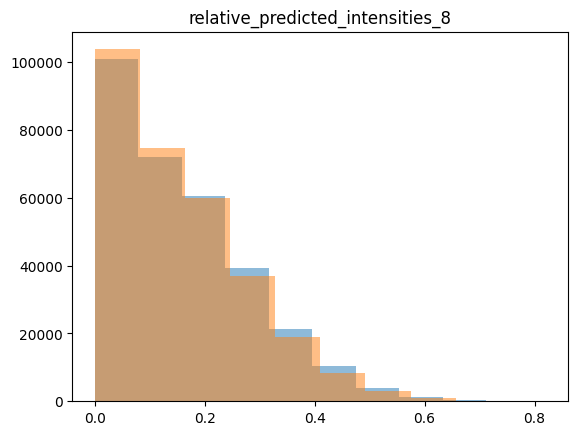

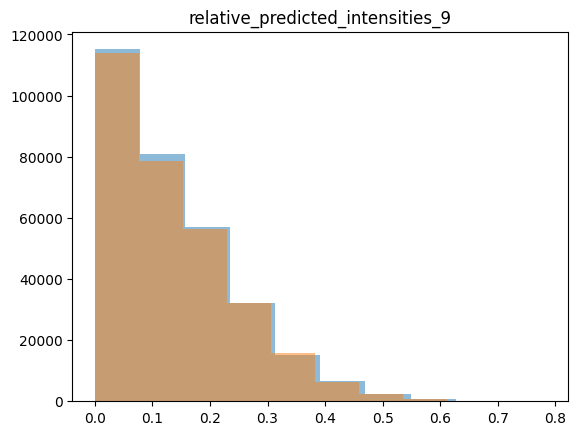

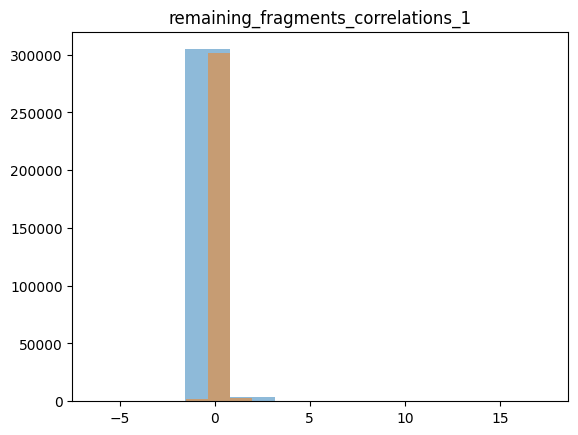

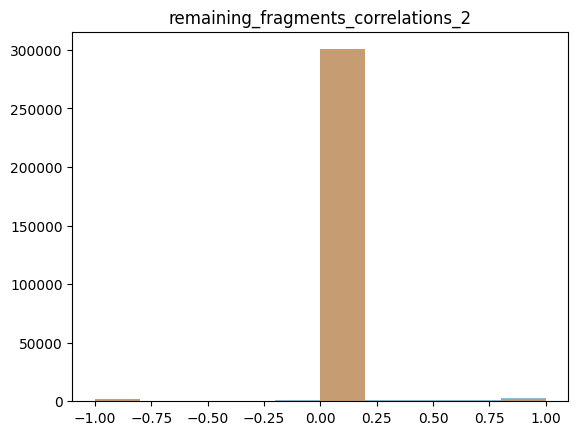

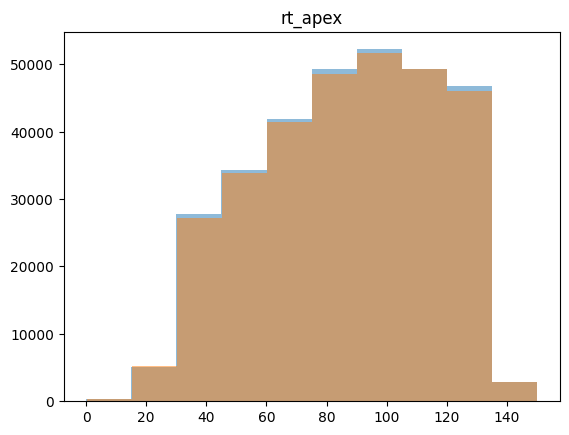

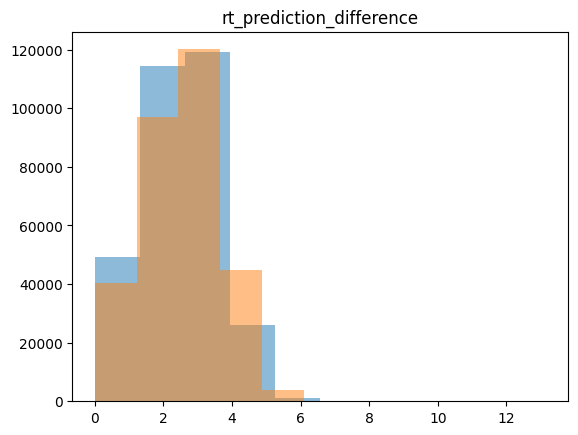

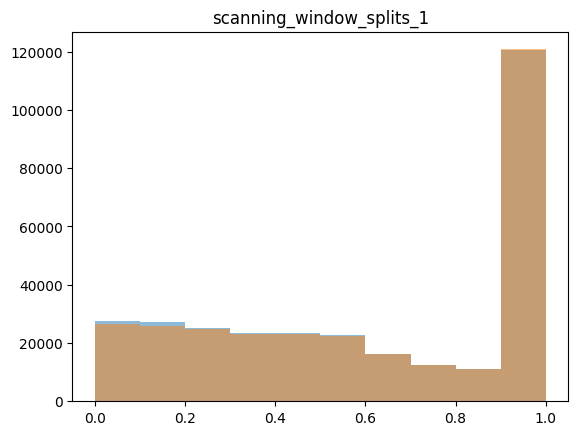

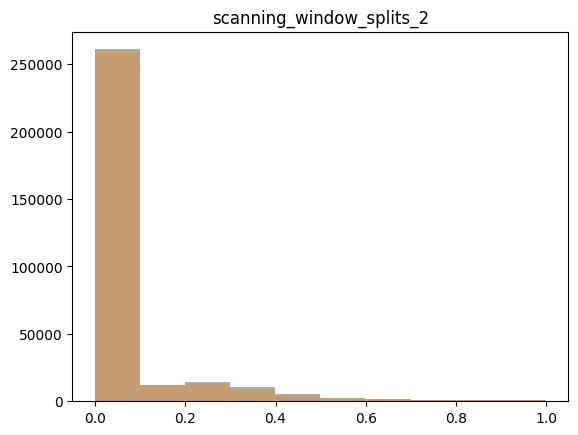

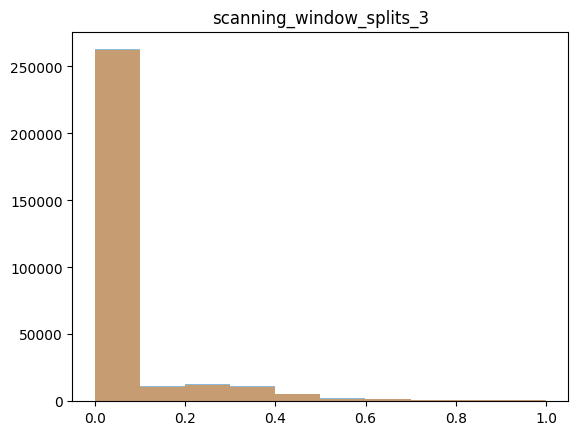

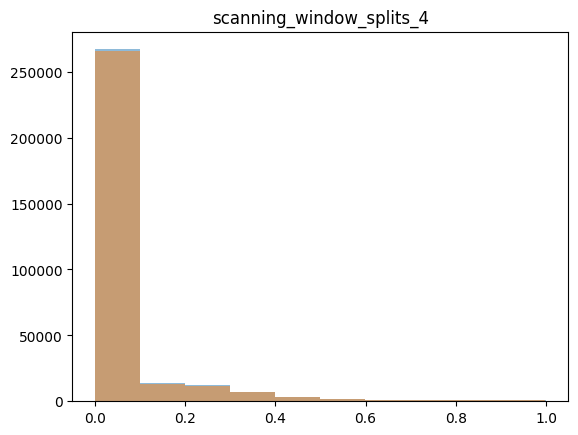

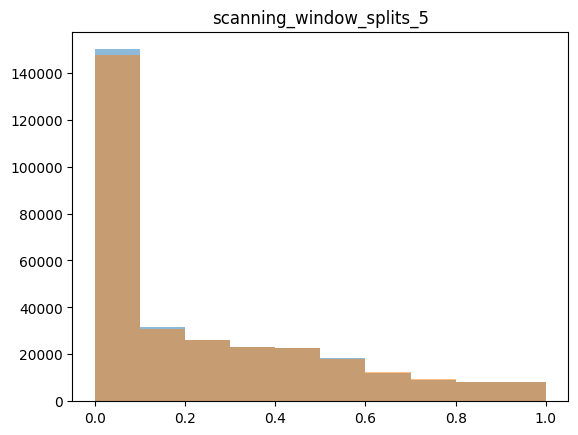

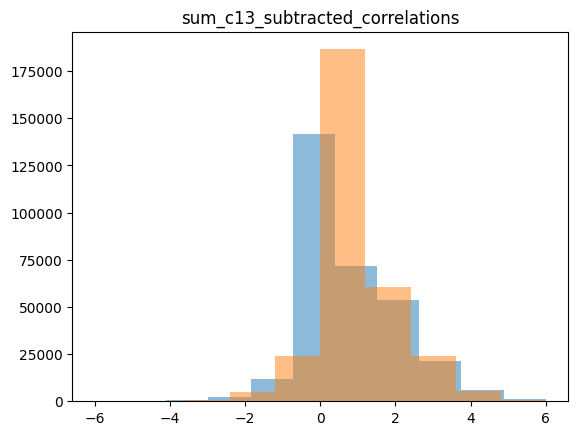

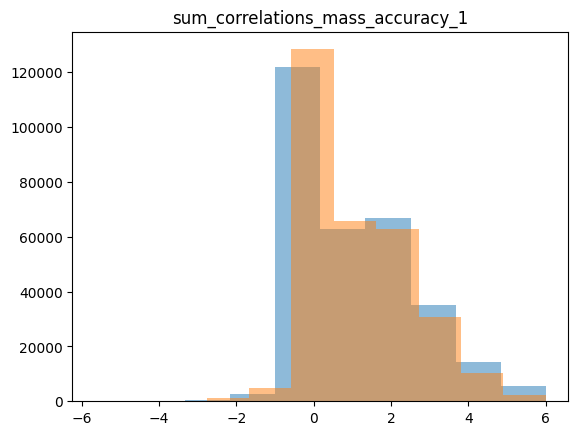

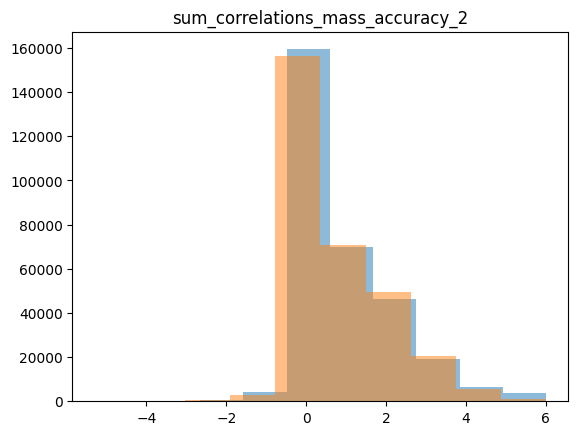

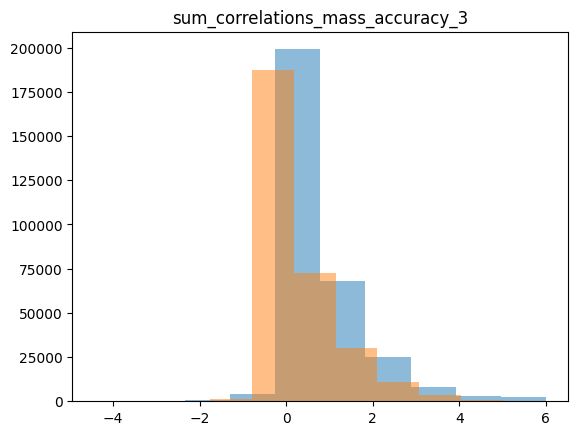

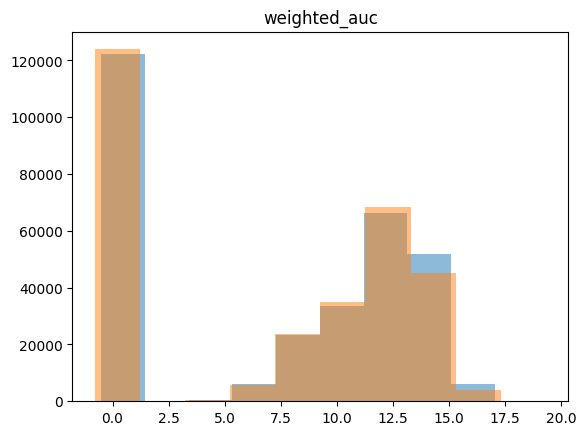

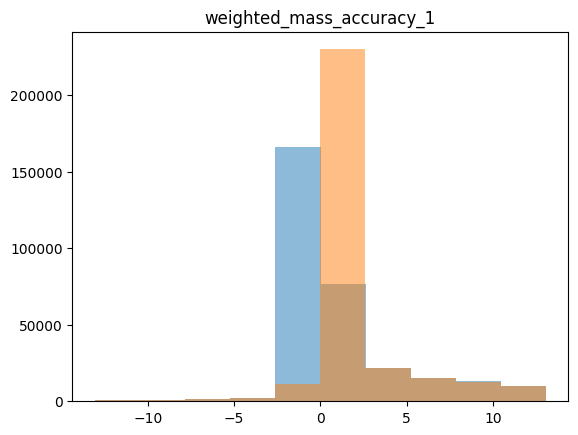

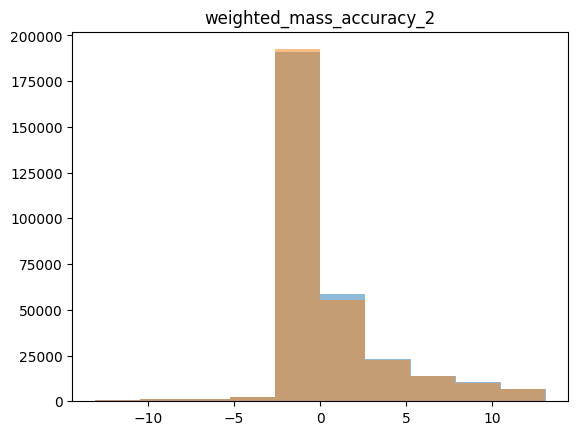

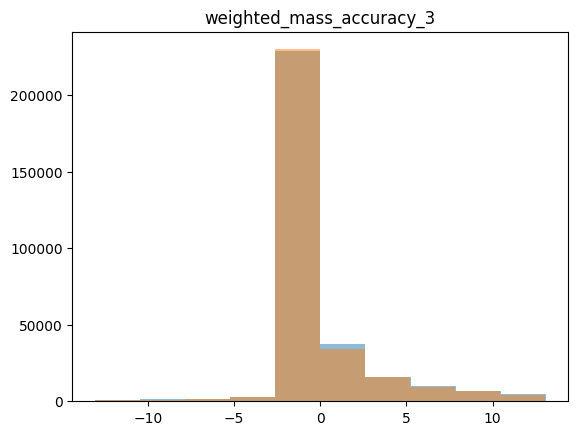

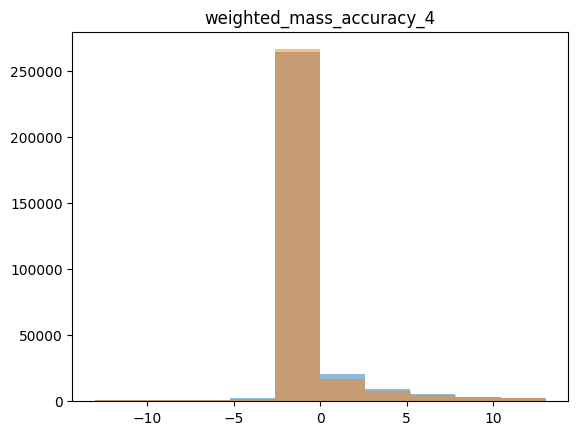

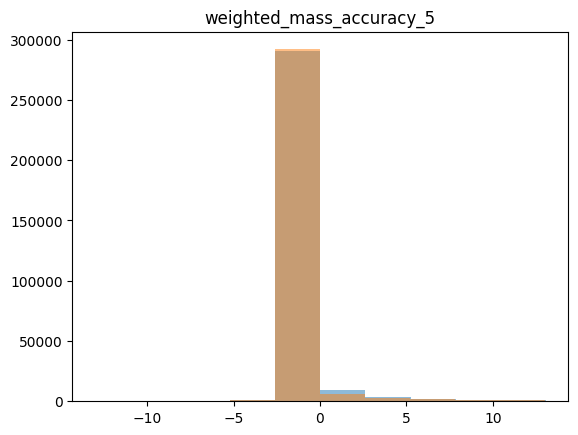

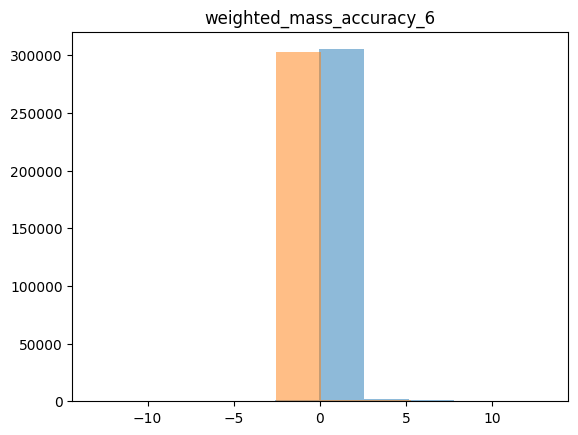

In [29]:
for c in features.columns:
    if pd.api.types.is_numeric_dtype(features[c]):
        plt.hist(df_targets[c], alpha=0.5)
        plt.hist(df_decoys[c], alpha=0.5)
        plt.title(c)

        plt.show()